In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [54]:
file_path = "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_featured_scaled.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(494420, 12)


,Latitude,Longitude,Hour,Month,Is_Weekend,Crime_Severity_Score,Primary_Type_Encoded,Location_Encoded,Season_Encoded,Day_Encoded,Arrest,Domestic
0,0.414795,-0.574671,-1.934739,1.623297,-0.623667,-0.768661,1.388772,0.959545,1.395977,0.504356,-0.580103,-0.457865
1,0.384649,-0.674220,0.580297,-0.166550,-0.623667,-0.768661,-0.572140,0.692181,0.483884,1.496725,1.723832,-0.457865
2,0.654239,0.826550,0.432354,0.131758,-0.623667,-0.768661,1.388772,-0.356712,0.483884,-1.480381,-0.580103,-0.457865
3,-0.062458,0.608249,-0.751193,1.324989,-0.623667,-0.768661,-0.486883,0.609915,-1.340302,0.504356,-0.580103,-0.457865
4,0.609538,-1.475956,-0.307363,-0.464858,-0.623667,-0.768661,0.280431,0.692181,-0.428209,0.504356,1.723832,-0.457865


In [55]:
geo_df = df[['Latitude','Longitude']].dropna()

print("Geo Dataset Shape:", geo_df.shape)

Geo Dataset Shape: (494420, 2)


In [56]:
cluster_sample = geo_df.sample(100000, random_state=42)
#cluster_sample = cluster_sample[cluster_sample['Latitude'] >= 37]

cluster_sample.head()

,Latitude,Longitude
402041,-0.038979,0.421286
168442,1.208311,0.228007
307255,0.436527,-1.390148
220323,-0.917411,0.840052
90875,0.608951,-0.981612


In [57]:
inertia = []

K_range = range(2,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_sample)
    inertia.append(kmeans.inertia_)

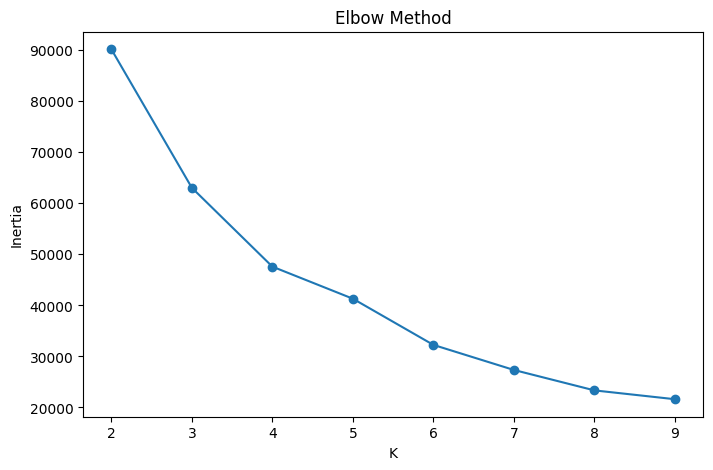

In [58]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.show()

In [59]:
kmeans = KMeans(n_clusters=5, random_state=42)

cluster_sample['KMeans_Cluster'] = kmeans.fit_predict(cluster_sample)

In [60]:
sil_sample = cluster_sample.sample(20000, random_state=42)

score = silhouette_score(
    sil_sample[['Latitude','Longitude']],
    sil_sample['KMeans_Cluster']
)

print("KMeans Silhouette Score:", score)

KMeans Silhouette Score: 0.3634839110289973


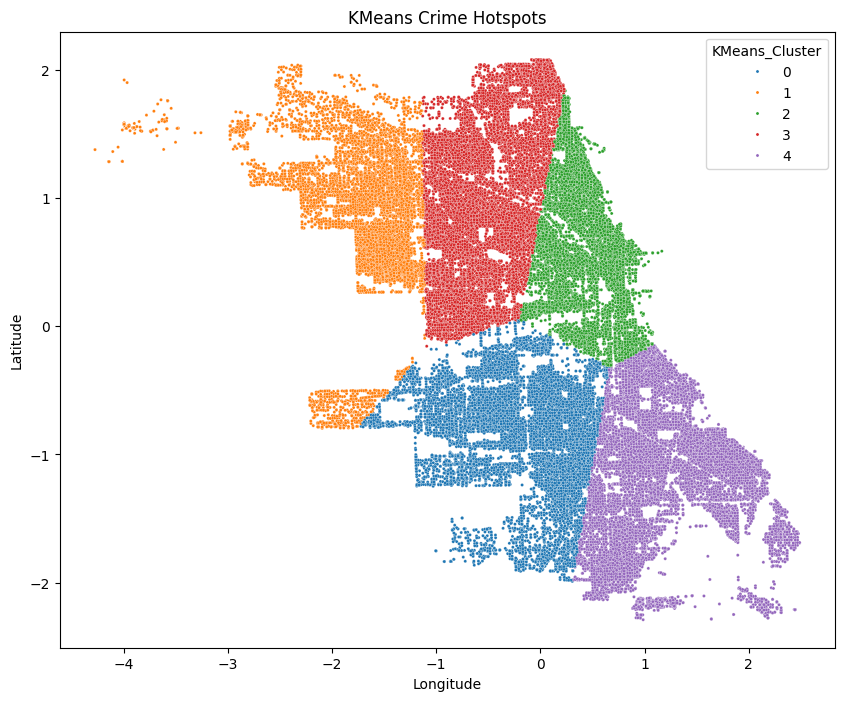

In [61]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=cluster_sample['Longitude'],
    y=cluster_sample['Latitude'],
    hue=cluster_sample['KMeans_Cluster'],
    palette='tab10',
    s=5
)

plt.title("KMeans Crime Hotspots")
plt.show()

In [62]:
db = DBSCAN(eps=0.005, min_samples=40)

cluster_sample['DBSCAN_Cluster'] = db.fit_predict(cluster_sample)

In [63]:
db_sil_sample = cluster_sample.sample(20000, random_state=42)

if len(set(db_sil_sample['DBSCAN_Cluster'])) > 1:
    db_score = silhouette_score(
        db_sil_sample[['Latitude','Longitude']],
        db_sil_sample['DBSCAN_Cluster']
    )
    print("DBSCAN Silhouette:", db_score)
else:
    print("DBSCAN produced single cluster / noise")

DBSCAN Silhouette: -0.727971598786113


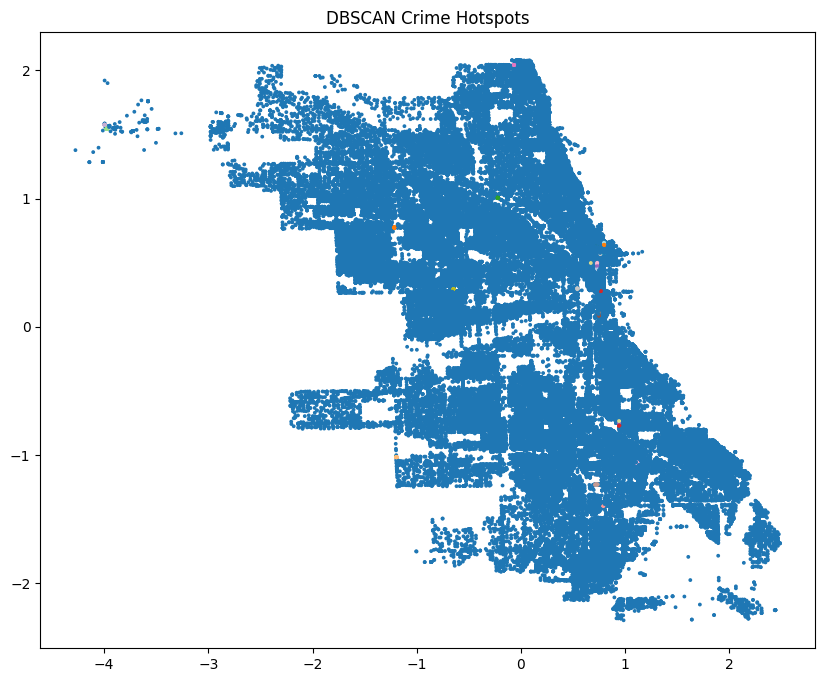

In [64]:
plt.figure(figsize=(10,8))

plt.scatter(
    cluster_sample['Longitude'],
    cluster_sample['Latitude'],
    c=cluster_sample['DBSCAN_Cluster'],
    cmap='tab20',
    s=3
)

plt.title("DBSCAN Crime Hotspots")
plt.show()

In [65]:
cluster_sample_small = cluster_sample.sample(5000, random_state=42)

hc = AgglomerativeClustering(n_clusters=5)

cluster_sample_small['Hierarchical_Cluster'] = hc.fit_predict(
    cluster_sample_small[['Latitude','Longitude']]
)

In [66]:
score = silhouette_score(
    cluster_sample_small[['Latitude','Longitude']],
    cluster_sample_small['Hierarchical_Cluster']
)

print("Hierarchical Silhouette:", score)

Hierarchical Silhouette: 0.33258753175477745


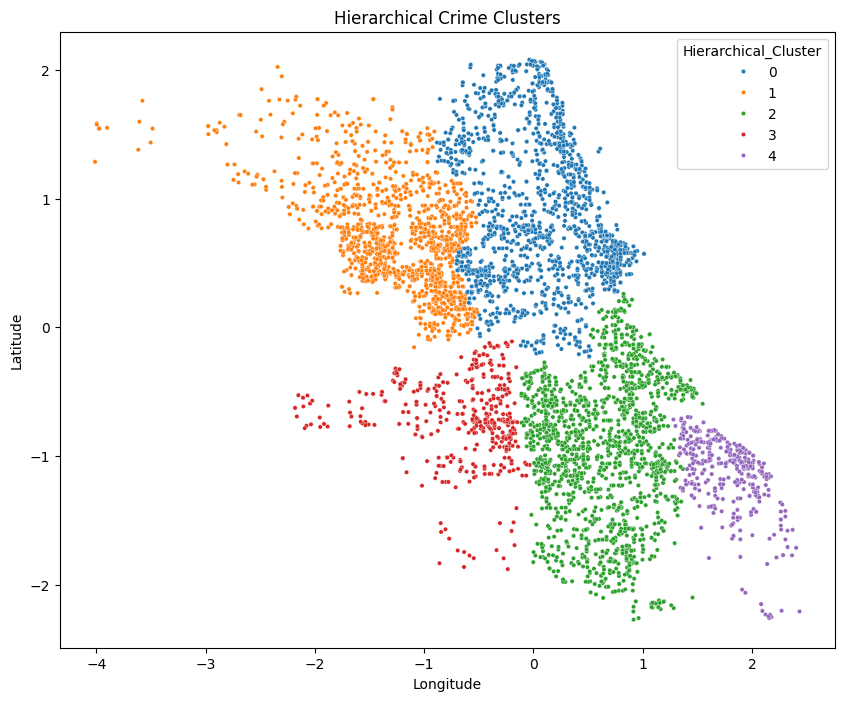

In [67]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=cluster_sample_small['Longitude'],
    y=cluster_sample_small['Latitude'],
    hue=cluster_sample_small['Hierarchical_Cluster'],
    palette='tab10',
    s=10
)

plt.title("Hierarchical Crime Clusters")
plt.show()

In [68]:
cluster_sample.to_csv(
    "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_hotspot_clusters.csv",
    index=False
)

print("Cluster Dataset Saved ✅")

Cluster Dataset Saved ✅


In [69]:
import joblib

joblib.dump(kmeans, "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/models/kmeans_model.pkl")

print("KMeans model saved ✅")

KMeans model saved ✅


In [70]:
joblib.dump(db, "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/models/dbscan_model.pkl")

print("DBSCAN model saved ✅")

DBSCAN model saved ✅


In [71]:
import mlflow
import os

mlflow.set_tracking_uri("file://" + os.path.abspath("../mlflow"))

In [72]:
mlflow.set_experiment("PatrolIQ_Clustering")

<Experiment: artifact_location='file:///Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/mlflow/315545030475946501', creation_time=1775372491735, experiment_id='315545030475946501', last_update_time=1775372491735, lifecycle_stage='active', name='PatrolIQ_Clustering', tags={}, workspace='default'>